# **Ievads attēlu apstrādē**
## **Praktiskais darbs Nr. 4**
---

**Students:** Rihards Irbe

**Studenta apliecības Nr.:** 251RDB259

**Saite uz programmēšanas kodu:** https://colab.research.google.com/drive/1_NEDKjdaoz85YCj0yCOetOCFvnbHxlq_?authuser=2#scrollTo=Gz_9b9xw5L_C&line=5&uniqifier=1

---

## **Programmas kods ar izvadi**

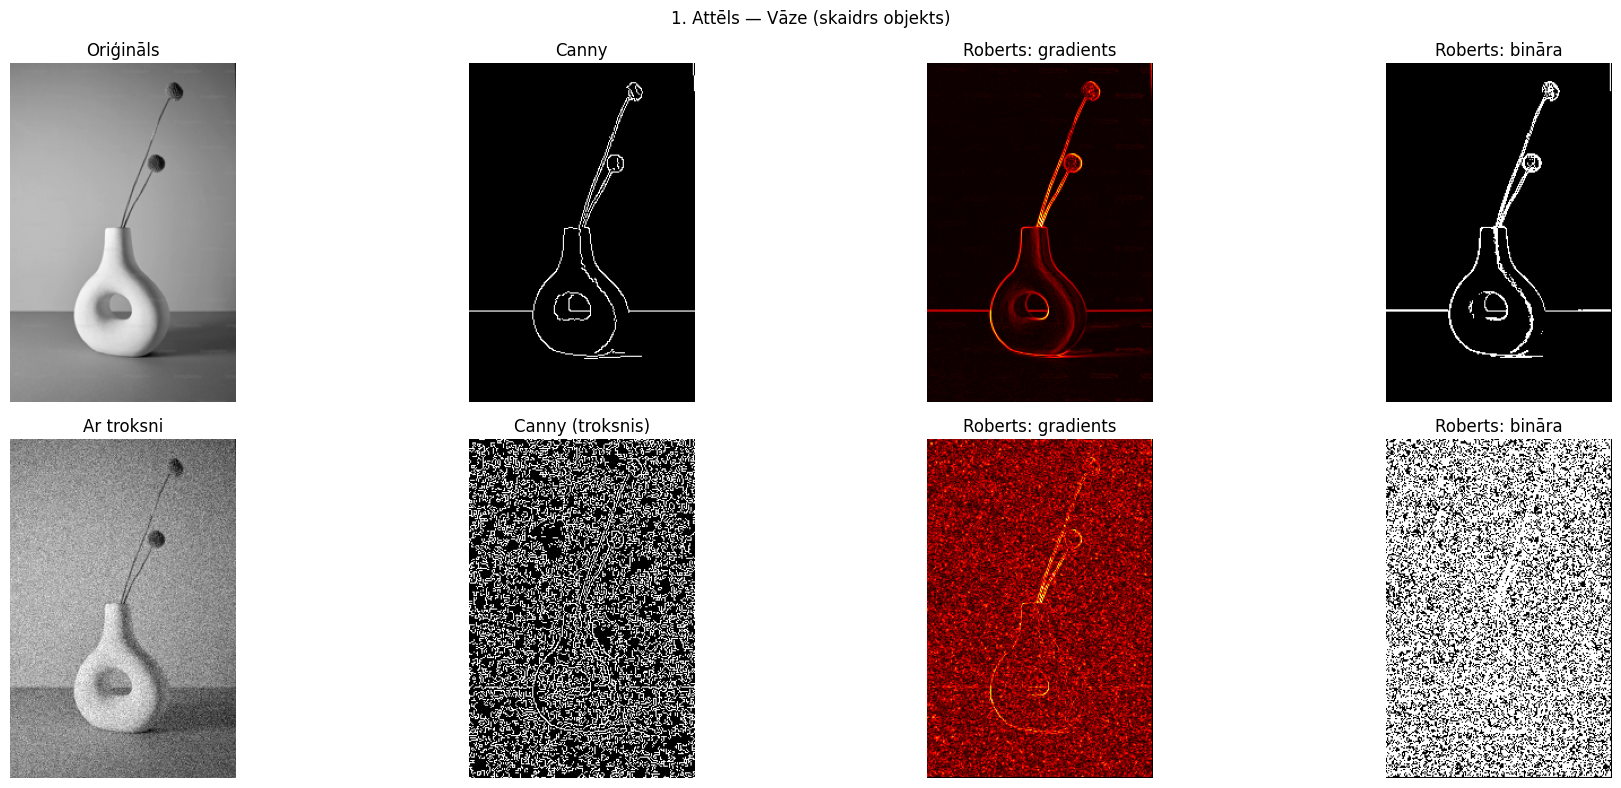

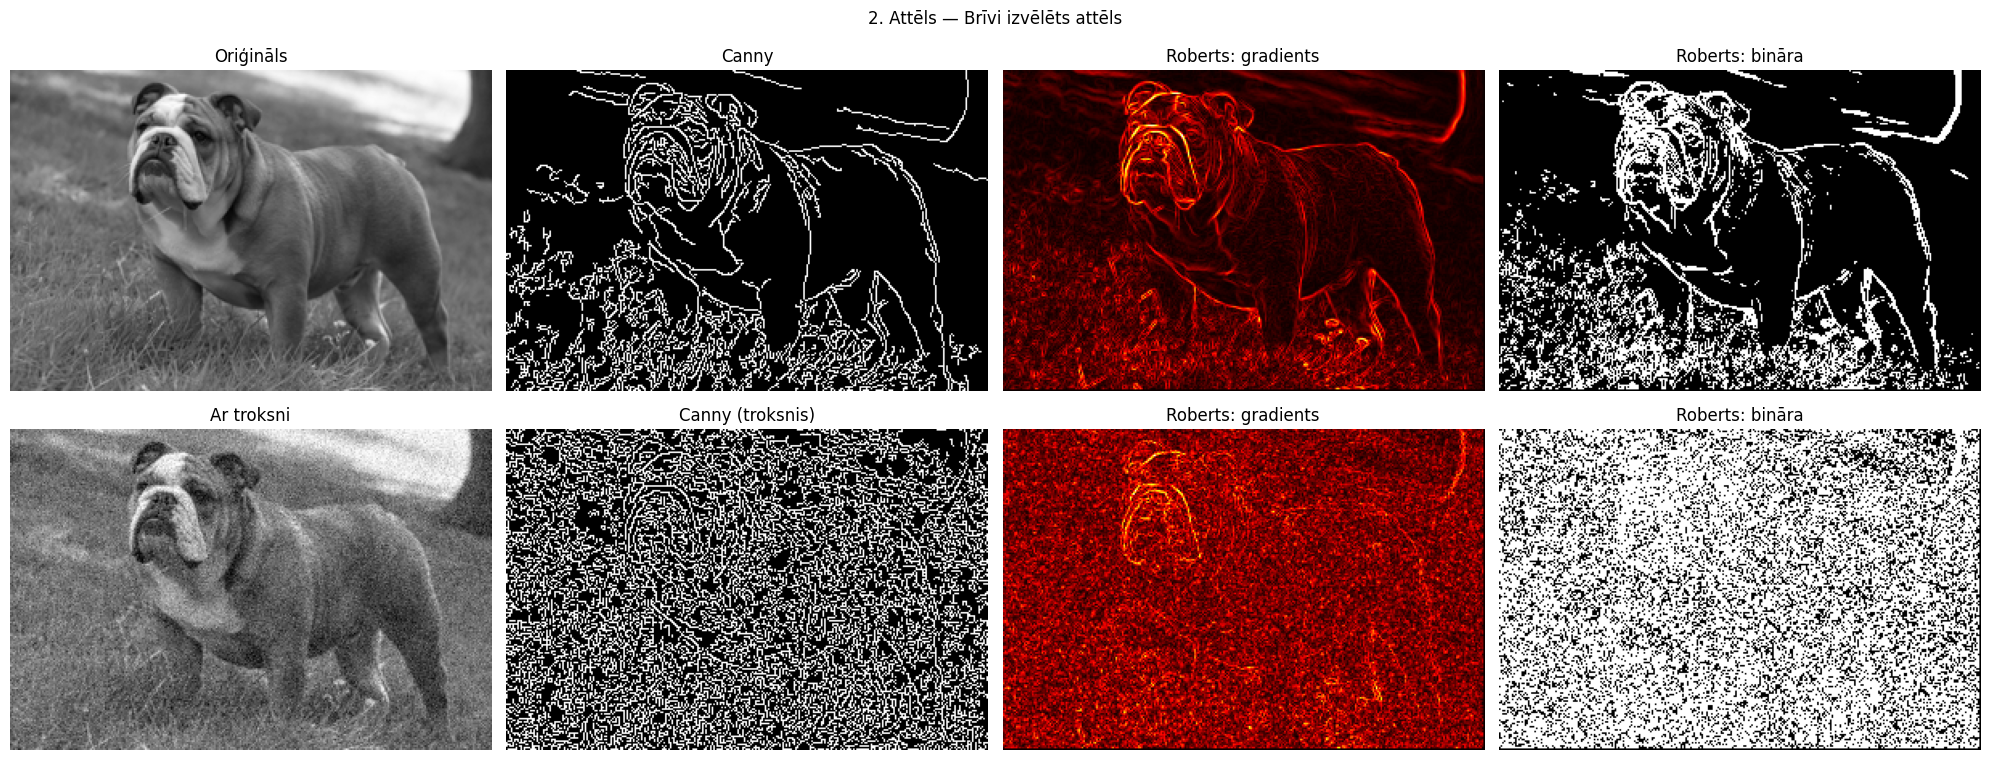

In [ ]:
from PIL import Image
import numpy as np
import requests
import cv2
from io import BytesIO
import matplotlib.pyplot as plt


GRADIENT_THRESHOLD = 20
CANNY_LOW          = 70
CANNY_HIGH         = 160

def load_image(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img.thumbnail((300, 300))
    return img


def add_gaussian_noise(image, sigma=25):
    width, height = image.size
    new_img = image.copy()
    pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]

            noise_r = int(np.random.normal(0, sigma))
            noise_g = int(np.random.normal(0, sigma))
            noise_b = int(np.random.normal(0, sigma))

            pixels[x, y] = (
                max(0, min(255, r + noise_r)),
                max(0, min(255, g + noise_g)),
                max(0, min(255, b + noise_b))
            )
    return new_img

def apply_roberts_operator(image):
    gray = image.convert("L")
    width, height = gray.size
    pixels = gray.load()

    grad_img = Image.new("L", (width, height))
    bin_img  = Image.new("L", (width, height))
    grad_pixels = grad_img.load()
    bin_pixels  = bin_img.load()

    gradient = [[0.0] * width for _ in range(height)]
    max_val = 0.0

    for x in range(width - 1):
        for y in range(height - 1):
            a = pixels[x,     y]
            b = pixels[x + 1, y]
            c = pixels[x,     y + 1]
            d = pixels[x + 1, y + 1]

            Gx = a - d
            Gy = b - c
            G  = (Gx ** 2 + Gy ** 2) ** 0.5

            gradient[y][x] = G
            if G > max_val:
                max_val = G

    for x in range(width):
        for y in range(height):
            G = gradient[y][x]

            if max_val > 0:
                grad_pixels[x, y] = int(G / max_val * 255)
            else:
                grad_pixels[x, y] = 0

            if G > GRADIENT_THRESHOLD:
                bin_pixels[x, y] = 255
            else:
                bin_pixels[x, y] = 0

    return grad_img, bin_img

def apply_canny(image, low=50, high=150):
    gray_np  = np.array(image.convert("L"))
    canny_np = cv2.Canny(gray_np, low, high)
    return Image.fromarray(canny_np)

def show_results(orig, noisy, canny_orig, roberts_grad_orig, roberts_bin_orig,
                 canny_noisy, roberts_grad_noisy, roberts_bin_noisy, title):

    plt.figure(figsize=(20, 8))

    imgs  = [orig.convert("L"), canny_orig, roberts_grad_orig, roberts_bin_orig,
             noisy.convert("L"), canny_noisy, roberts_grad_noisy, roberts_bin_noisy]

    names = ["Oriģināls", "Canny", "Roberts: gradients", "Roberts: bināra",
             "Ar troksni", "Canny (troksnis)", "Roberts: gradients", "Roberts: bināra"]

    cmaps = ["gray", "gray", "hot", "gray",
             "gray", "gray", "hot", "gray"]

    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(imgs[i], cmap=cmaps[i])
        plt.title(names[i])
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

url1 = "https://plus.unsplash.com/premium_photo-1668704252725-52cc74ef3f39?fm=jpg&q=60&w=3000&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MXx8b2JqZWN0fGVufDB8fDB8fHww"
url2 = "https://breed-assets.wisdompanel.com/dog/bulldog-standard/Bulldog2.png"

test_images = [
    ("1. Attēls — Vāze (skaidrs objekts)", url1),
    ("2. Attēls — Brīvi izvēlēts attēls",   url2),
]

for title, url in test_images:

    orig  = load_image(url)
    noisy = add_gaussian_noise(orig, sigma=25)

    canny_orig  = apply_canny(orig,  CANNY_LOW, CANNY_HIGH)
    canny_noisy = apply_canny(noisy, CANNY_LOW, CANNY_HIGH)

    roberts_grad_orig,  roberts_bin_orig  = apply_roberts_operator(orig)
    roberts_grad_noisy, roberts_bin_noisy = apply_roberts_operator(noisy)

    show_results(
        orig, noisy,
        canny_orig,  roberts_grad_orig,  roberts_bin_orig,
        canny_noisy, roberts_grad_noisy, roberts_bin_noisy,
        title
    )

# **Secinājumi**

*Kādas atšķirības ir redzamas starp dažādiem malu noteikšanas algoritmiem?

Ar manis izvēlētajiem parametriem Canny algoritms neparādīja objektu tik detalizēti kā Roberta algoritms, Mans izvēlētais min ir 60 un max 160, kas parādīja objekta figūru, bet ļoti nedetalizēti, savukārt Roberta algoritms to parādīja ar labāku kvalitāti.

*Kura metode labāk identificē objektu malas un kādu ietekmi uz rezultātiem atstāj troksnis?

Skaidrā attēlā Roberta metode identificēja malas detalizētāk ar izvēlētajiem parametriem. Tomēr trokšņaina attēla gadījumā Canny algoritms sniedza labākus rezultātus

*Kādas ir katras metodes priekšrocības un trūkumi?

Canny

Priekšrocības:
Labāk nosaka malas trokšņu situācijā

Trūkumi:
Vairāki parametri un šos parametrus ir jānosaka precīzi iekš diapazonās, savadāk iznākums nebūs kā iecerēts.

Roberta

Prieksrocības: Mazāk jānosaka parametri, Rada detalizētāku attēlu bez trokšņa.

Trūkumi: Sliktāk nosaka malas trokšņu situācijā

*Kā algoritmi darbojas dažāda tipa attēlos?

Attēlos ar skaidri redzamu objektu šie algoritmi tika labi galā, lai izvadītu pareizu attēla objekta "outline". Savukārt ar attēlu, kur ir vairāk detaļas tika zaudēta kvalitāte un palika grūtāk saprast, kas tikka attēlots pēc algoritmu pielietošanas. Canny izlaida vājākās malas starp sīkām detaļām, jo tās nesasniedza augšējo diapazonu.
